### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [38]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw_df = pd.read_csv('./data/marketing_campaign.csv', delimiter='\t', index_col='ID')
raw_df.head()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,5,0,0,0,0,0,0,3,11,0


In [39]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int

In [40]:
from mlpeople.eda import describe_dataframe

describe_dataframe(raw_df)

,column_id,data_type,unique_values,missing_values,mean,std,min,max
0,Year_Birth,int64,59,0,1968.81,11.98,1893.0,1996.0
1,Education,object,5,0,NaN,NaN,NaN,NaN
2,Marital_Status,object,8,0,NaN,NaN,NaN,NaN
3,Income,float64,1974,24,52247.25,25173.08,1730.0,666666.0
4,Kidhome,int64,3,0,0.44,0.54,0.0,2.0
5,Teenhome,int64,3,0,0.51,0.54,0.0,2.0
6,Dt_Customer,object,663,0,NaN,NaN,NaN,NaN
7,Recency,int64,100,0,49.11,28.96,0.0,99.0
8,MntWines,int64,776,0,303.94,336.60,0.0,1493.0
9,MntFruits,int64,158,0,26.30,39.77,0.0,199.0


<span style="display: block; background-color: #f60">

* The dataset contains **2240 records** and **28 features**.
* Most columns are numeric with type `int64`.
* There are **3 categorical** columns and **1 float** column.
* Missing values are present **only in the `Income` column** (24 records).
* The `Dt_Customer` column is stored as `object` and should be converted to a datetime type during data preprocessing.

</span>

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [41]:
raw_df["Income"].describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

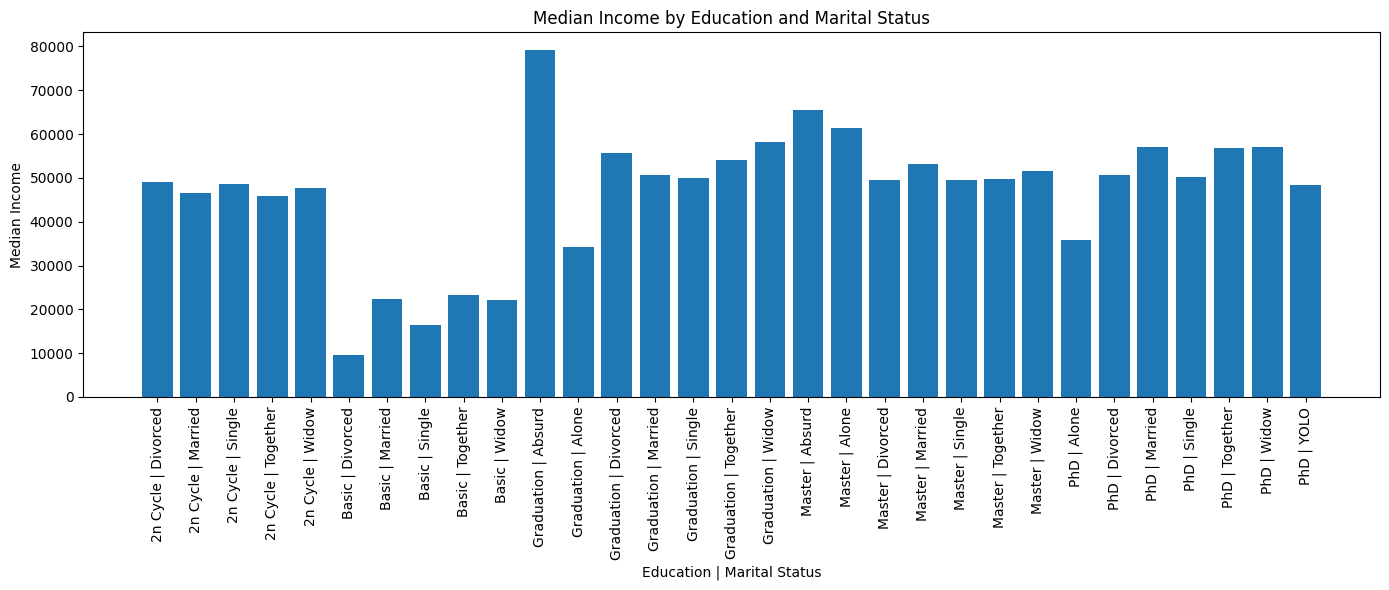

In [42]:
# Compute median income per group
group_medians = (
    raw_df
    .groupby(['Education', 'Marital_Status'])['Income']
    .median()
    .reset_index()
)

# Create a label for plotting
group_medians['Group'] = (
    group_medians['Education'] + " | " + group_medians['Marital_Status']
)

# Plot with matplotlib
plt.figure(figsize=(14, 6))
plt.bar(group_medians['Group'], group_medians['Income'])
plt.xticks(rotation=90)
plt.xlabel('Education | Marital Status')
plt.ylabel('Median Income')
plt.title('Median Income by Education and Marital Status')
plt.tight_layout()
plt.show()

In [43]:
# fill missing income values with median value per Education/Marital_Status group
raw_df['Income'] = (
    raw_df.groupby(['Education', 'Marital_Status'])['Income']
          .transform(lambda s: s.fillna(s.median()))
)

<span style="display: block; background-color: #f60">

The `Income` feature is numeric, widely distributed, and crucial for customer segmentation.
Since clustering algorithms rely on distance calculations, using mode or mean imputation might distort the data distribution and create artificial density.

Therefore, missing values were filled using the **median income within groups of customers sharing the same Education and Marital_Status**.
This approach preserves the natural structure of the data and leads to more meaningful clusters.

</span>

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [44]:
# Process categorical columns — One-Hot Encoding
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['Education', 'Marital_Status']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_array = encoder.fit_transform(raw_df[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols)


encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoded_cols,
    index=raw_df.index
)

df_encoded = pd.concat(
    [raw_df.drop(columns=categorical_cols), encoded_df],
    axis=1
)

In [47]:
df_encoded['Dt_Customer'] = pd.to_datetime(
    df_encoded['Dt_Customer'],
    format='%d-%m-%Y'
)

reference_date = df_encoded['Dt_Customer'].max()

# tenure is the most meaningful feature for segmentation
df_encoded['Customer_Tenure_Days'] = (
    reference_date - df_encoded['Dt_Customer']
).dt.days

# additional datetime features
df_encoded['Customer_Year'] = df_encoded['Dt_Customer'].dt.year
df_encoded['Customer_Month'] = df_encoded['Dt_Customer'].dt.month
df_encoded['Customer_Weekday'] = df_encoded['Dt_Customer'].dt.day_of_week

In [48]:
df_encoded[['Dt_Customer', 'Customer_Tenure_Days', 'Customer_Year', 'Customer_Month', 'Customer_Weekday']]

,Dt_Customer,Customer_Tenure_Days,Customer_Year,Customer_Month,Customer_Weekday
ID,,,,,
5524,2012-09-04,663,2012,9,1
2174,2014-03-08,113,2014,3,5
4141,2013-08-21,312,2013,8,2
6182,2014-02-10,139,2014,2,0
5324,2014-01-19,161,2014,1,6
...,...,...,...,...,...
10870,2013-06-13,381,2013,6,3
4001,2014-06-10,19,2014,6,1
7270,2014-01-25,155,2014,1,5


<span style="display: block; background-color: #f60">

* Categorical features (`Education`, `Marital_Status`) were transformed using One-Hot Encoding to avoid introducing artificial ordinal relationships between categories, which is critical for distance-based clustering.

* The date column (`Dt_Customer`) was converted into a numeric feature representing customer tenure in days. This reflects how long a customer has been with the company and is meaningful for segmentation while remaining compatible with clustering algorithms.

* Additionally, year, month, and day-of-week components were extracted from `Dt_Customer` to capture potential seasonal and temporal patterns in customer behavior as separate numeric features.

</span>

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [49]:
df_encoded.columns

Index(['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact',
       'Z_Revenue', 'Response', 'Education_2n Cycle', 'Education_Basic',
       'Education_Graduation', 'Education_Master', 'Education_PhD',
       'Marital_Status_Absurd', 'Marital_Status_Alone',
       'Marital_Status_Divorced', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Together',
       'Marital_Status_Widow', 'Marital_Status_YOLO', 'Customer_Tenure_Days',
       'Customer_Year', 'Customer_Month', 'Customer_Weekday'],
      dtype='object')

In [51]:
# Create working copy of the dataset for clustering
X = df_encoded.copy()

# Aggregate all spending-related features into a single variable
# This reduces multicollinearity and simplifies the customer spending signal
X['Total_Spend'] = (
    X['MntWines'] +
    X['MntFruits'] +
    X['MntMeatProducts'] +
    X['MntFishProducts'] +
    X['MntSweetProducts'] +
    X['MntGoldProds']
)

# Drop redundant and low-information features for clustering
drop_cols = [

    # Original spending components (replaced by Total_Spend)
    'MntWines','MntFruits','MntMeatProducts','MntFishProducts',
    'MntSweetProducts','MntGoldProds',

    # Raw and derived date features
    # Customer_Tenure_Days is kept, others removed to avoid redundancy
    'Dt_Customer','Customer_Year','Customer_Month','Customer_Weekday',

    # Constant or near-constant columns (no variance → no clustering value)
    'Z_CostContact','Z_Revenue',

    # Campaign acceptance indicators
    # These are sparse, event-driven features more suitable for supervised learning
    'AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5','Response','Complain',

    # Purchase channel breakdown
    # These are highly correlated with overall spending and may introduce redundancy
    'NumCatalogPurchases','NumWebPurchases','NumStorePurchases',
]

# Apply feature reduction
X = X.drop(columns=drop_cols)

# Inspect resulting dataset
X.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebVisitsMonth,Education_2n Cycle,Education_Basic,Education_Graduation,...,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Customer_Tenure_Days,Total_Spend
ID,,,,,,,,,,,,,,,,,,,,,
5524,1957,58138.0,0,0,58,3,7,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,663,1617
2174,1954,46344.0,1,1,38,2,5,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,113,27
4141,1965,71613.0,0,0,26,1,4,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,312,776
6182,1984,26646.0,1,0,26,2,6,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,139,53
5324,1981,58293.0,1,0,94,5,5,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,161,422


In [52]:
from sklearn.cluster import KMeans

# Prepare data
X_model = X.copy()

# Fit KMeans (3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_model)

# Attach cluster labels to dataset
X_model['Cluster'] = labels

In [53]:
# Compute silhouette score
from sklearn.metrics import silhouette_score

score = silhouette_score(X_model.drop(columns=['Cluster']), labels)

print(f"Silhouette Score (k=3): {score:.4f}")

Silhouette Score (k=3): 0.6002


<span style="display: block; background-color: #f60">

* KMeans clustering was performed with 3 clusters on a reduced feature set, where most original variables were dropped to remove redundancy, constant features, and highly correlated or low-signal attributes. Key information was preserved through feature engineering, including aggregated spending (Total_Spend) and customer tenure.

* The resulting model achieved a silhouette score of 0.6002, indicating reasonably well-separated clusters and confirming that the selected features capture meaningful structure in customer behavior.

</span>







**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [64]:
def plot_2d_scatter_cluster(
    X, col1, col2,
    title=None,
    xlabel=None,
    ylabel=None,
    figsize=(8,6),
):
    # default params
    if title is None:
        title = f'Clusters: {col1} vs {col2}'
    
    if xlabel is None:
        xlabel = col1
    
    if ylabel is None:
        ylabel = col2
    
    plt.figure(figsize=figsize)

    plt.scatter(
        X[col1],
        X[col2],
        c=X['Cluster'],
        cmap='viridis',
        alpha=0.7
    )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

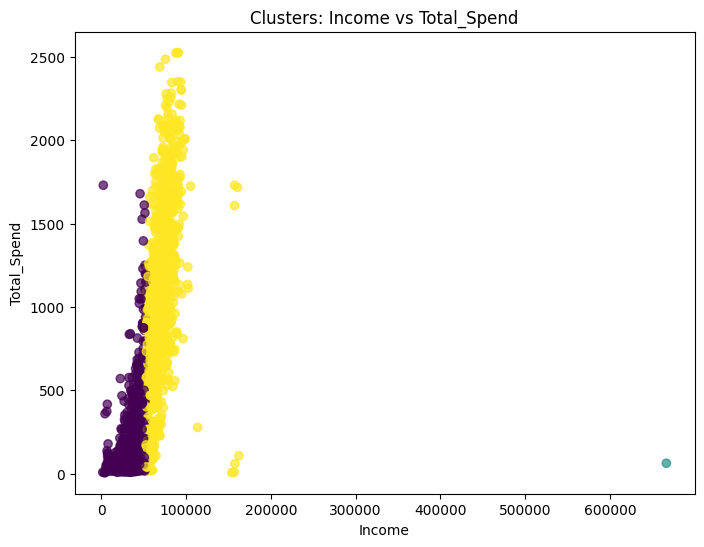

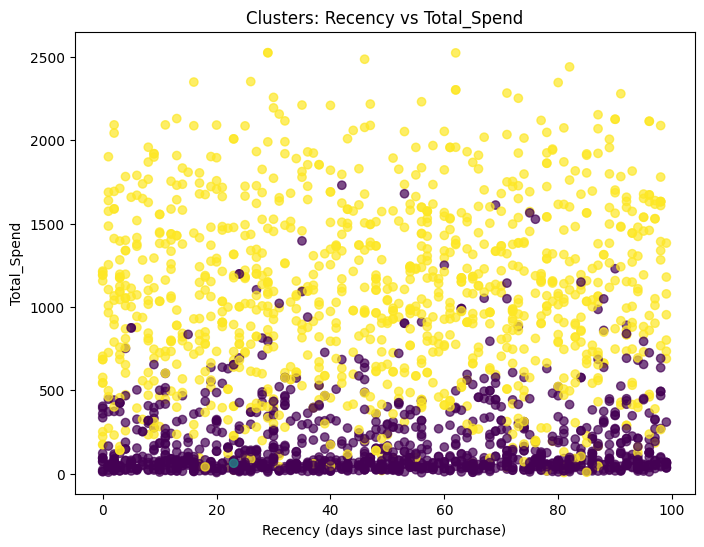

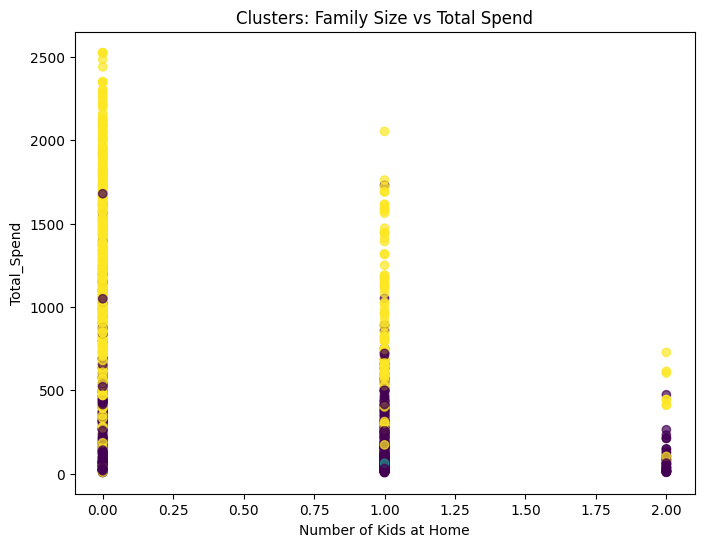

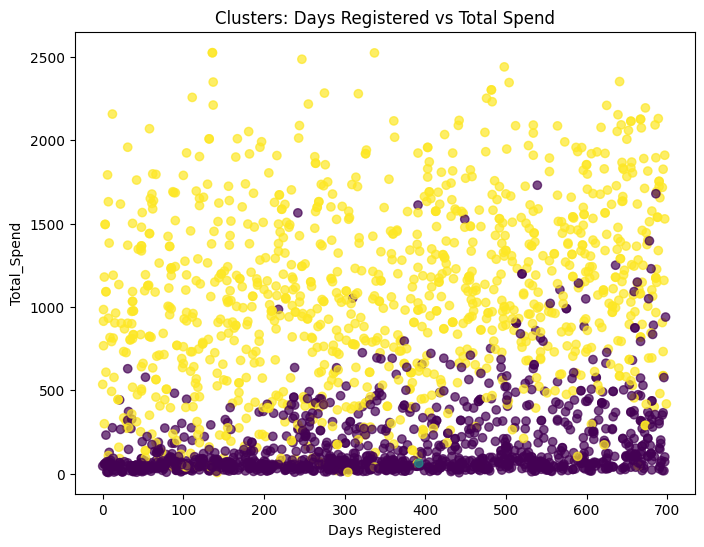

In [73]:
# Plot 1: Income vs Total Spend
plot_2d_scatter_cluster(X_model, 'Income', 'Total_Spend')

# Plot 2: Recency vs Total Spend
plot_2d_scatter_cluster(X_model, 'Recency', 'Total_Spend', xlabel='Recency (days since last purchase)')

# Plot 3: Kidhome vs Total Spend
plot_2d_scatter_cluster(X_model, 'Kidhome', 'Total_Spend', xlabel='Number of Kids at Home', title='Clusters: Family Size vs Total Spend')

# Plot 4: Tenure vs Total Spend
plot_2d_scatter_cluster(X_model, 'Customer_Tenure_Days', 'Total_Spend', xlabel='Days Registered', title='Clusters: Days Registered vs Total Spend')

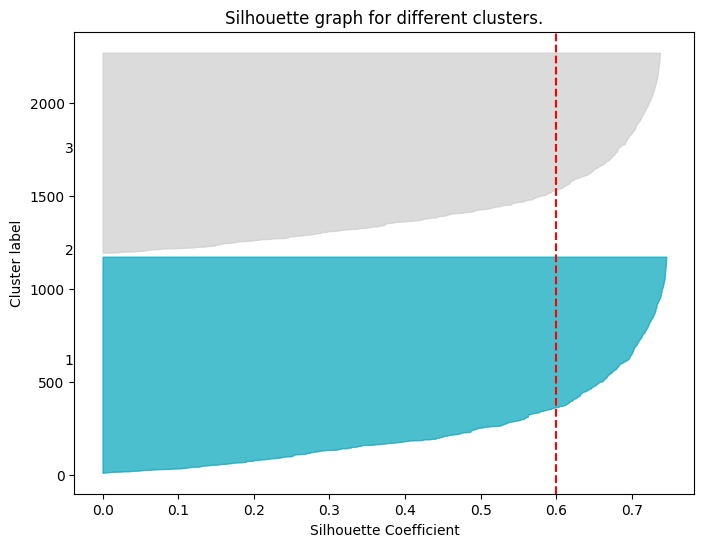

In [ ]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

sil_vals = silhouette_samples(X_model.drop(columns=['Cluster']), X_model['Cluster'])
silhouette_avg = silhouette_score(X_model.drop(columns=['Cluster']), X_model['Cluster'])

plt.figure(figsize=(8,6))

y_lower = 10
i = 0

for cluster in np.unique(X_model['Cluster']):
    i = i + 1
    ith_cluster_silhouette_values = sil_vals[X_model['Cluster'] == cluster]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / len(np.unique(X_model['Cluster'])))
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    y_lower = y_upper + 10


plt.xlabel('Silhouette Coefficient')
plt.ylabel('Cluster label')
plt.title('Silhouette graph for different clusters.')

plt.axvline(x=silhouette_avg, color="red", linestyle="--")

plt.show()

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?